<a href="https://colab.research.google.com/github/algaalex/Gaussian-Processes-GANs-GNNs/blob/main/02_octmnist_dcgan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 2.1 — OCTMNIST Retinal Images with a DCGAN

This notebook downloads and explores OCTMNIST, trains an unconditional DCGAN,
plots losses, creates real-versus-generated image grids and computes FID. An
optional conditional-GAN extension is included at the end.



In [1]:
import sys
import subprocess

try:
    import medmnist
    from torchmetrics.image.fid import FrechetInceptionDistance
except ImportError:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "medmnist>=3.0.2",
            "torchmetrics[image]>=1.3",
            "torch-fidelity>=0.3.0",
        ]
    )



In [2]:
import json
import random
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from medmnist import INFO, OCTMNIST
from torch import nn
from torch.utils.data import DataLoader, Subset
from torchmetrics.image.fid import FrechetInceptionDistance
from torchvision import transforms
from torchvision.utils import make_grid
from tqdm.auto import tqdm



In [3]:
# ----------------------------- Configuration -----------------------------
QUICK_RUN = False
RUN_CGAN_EXTENSION = False  # Optional extra-credit experiment.
SEED = 42
IMAGE_SIZE = 32
LATENT_DIM = 100
BATCH_SIZE = 256
EPOCHS = 2 if QUICK_RUN else 20
LEARNING_RATE = 2e-4
MAX_TRAIN_SAMPLES = 10_000 if QUICK_RUN else None
FID_SAMPLES = 1_000 if QUICK_RUN else 5_000
OUTPUT_DIR = Path("outputs/octmnist")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_WORKERS = 2 if torch.cuda.is_available() else 0
print(f"Using device: {DEVICE}")


def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed()



Using device: cuda


## 1. Load, inspect and transform OCTMNIST

The original 28x28 grayscale images are resized to 32x32 so that the DCGAN can
repeatedly double a 4x4 feature map. Pixel values are normalised to [-1, 1]
because the generator's final activation is Tanh.



100%|██████████| 54.9M/54.9M [01:28<00:00, 623kB/s]


Class names: {0: 'choroidal neovascularization', 1: 'diabetic macular edema', 2: 'drusen', 3: 'normal'}
Train: 97,477; validation: 10,832; test: 1,000


,class_id,class_name,count,percentage
0,0,choroidal neovascularization,33484,34.350667
1,1,diabetic macular edema,10213,10.477343
2,2,drusen,7754,7.954697
3,3,normal,46026,47.217292


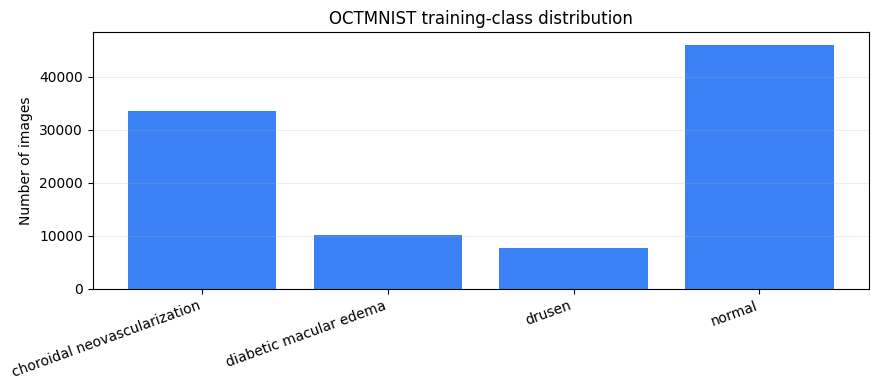

In [4]:
transform = transforms.Compose(
    [
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,)),
    ]
)

train_full = OCTMNIST(split="train", transform=transform, download=True, size=28)
val_dataset = OCTMNIST(split="val", transform=transform, download=True, size=28)
test_dataset = OCTMNIST(split="test", transform=transform, download=True, size=28)

info = INFO["octmnist"]
CLASS_NAMES = {int(key): value for key, value in info["label"].items()}
NUM_CLASSES = len(CLASS_NAMES)
print("Class names:", CLASS_NAMES)
print(f"Train: {len(train_full):,}; validation: {len(val_dataset):,}; test: {len(test_dataset):,}")

labels = np.asarray(train_full.labels).reshape(-1)
class_counts = pd.DataFrame(
    {
        "class_id": sorted(CLASS_NAMES),
        "class_name": [CLASS_NAMES[i] for i in sorted(CLASS_NAMES)],
        "count": [int((labels == i).sum()) for i in sorted(CLASS_NAMES)],
    }
)
class_counts["percentage"] = 100 * class_counts["count"] / class_counts["count"].sum()
display(class_counts)
class_counts.to_csv(OUTPUT_DIR / "octmnist_class_distribution.csv", index=False)

plt.figure(figsize=(9, 4))
plt.bar(class_counts["class_name"], class_counts["count"], color="#3b82f6")
plt.title("OCTMNIST training-class distribution")
plt.ylabel("Number of images")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "class_distribution.png", dpi=220, bbox_inches="tight")
plt.show()



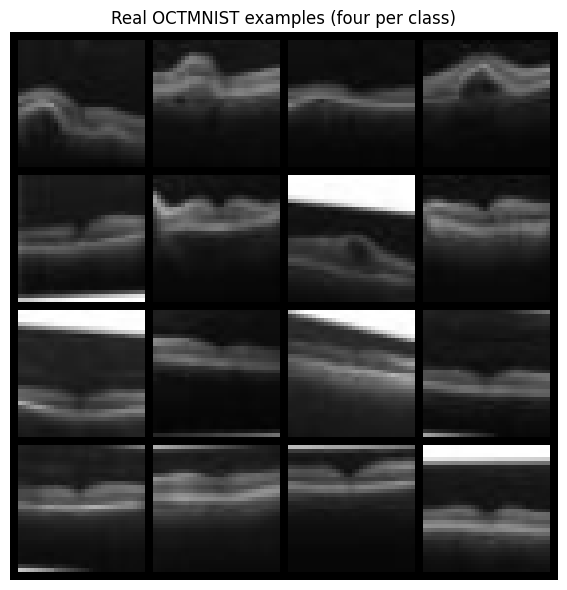

Images used for GAN training: 97,477


In [5]:
def denormalise(images: torch.Tensor) -> torch.Tensor:
    return ((images.detach().cpu() + 1) / 2).clamp(0, 1)


def show_grid(images: torch.Tensor, title: str, path: Path, nrow: int = 8) -> None:
    grid = make_grid(denormalise(images), nrow=nrow, padding=2)
    plt.figure(figsize=(10, 6))
    plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray", vmin=0, vmax=1)
    plt.axis("off")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(path, dpi=220, bbox_inches="tight")
    plt.show()


# Select four examples per class so the exploration is not dominated by one class.
sample_indices: list[int] = []
for class_id in sorted(CLASS_NAMES):
    sample_indices.extend(np.flatnonzero(labels == class_id)[:4].tolist())
sample_images = torch.stack([train_full[index][0] for index in sample_indices])
show_grid(sample_images, "Real OCTMNIST examples (four per class)", OUTPUT_DIR / "real_samples.png", nrow=4)

if MAX_TRAIN_SAMPLES is not None and MAX_TRAIN_SAMPLES < len(train_full):
    rng = np.random.default_rng(SEED)
    subset_indices = rng.choice(len(train_full), MAX_TRAIN_SAMPLES, replace=False).tolist()
    train_dataset = Subset(train_full, subset_indices)
else:
    train_dataset = train_full

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    drop_last=True,
)
print(f"Images used for GAN training: {len(train_dataset):,}")



## 2. DCGAN architecture

The generator maps a 100-dimensional noise vector to a 32x32 image through
transposed convolutions. The discriminator uses strided convolutions to reduce
the image to one real/fake logit. Batch normalisation stabilises intermediate
feature scales; LeakyReLU prevents inactive discriminator units.



In [6]:
class OCTGenerator(nn.Module):
    def __init__(self, latent_dim: int = LATENT_DIM):
        super().__init__()
        self.network = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, 256, 4, 1, 0, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 1, 4, 2, 1, bias=False),
            nn.Tanh(),
        )

    def forward(self, noise: torch.Tensor) -> torch.Tensor:
        return self.network(noise)


class OCTDiscriminator(nn.Module):
    def __init__(self, input_channels: int = 1):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(input_channels, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 1, 4, 1, 0, bias=False),
        )

    def forward(self, images: torch.Tensor) -> torch.Tensor:
        return self.network(images).view(-1)


def initialise_weights(module: nn.Module) -> None:
    classname = module.__class__.__name__
    if "Conv" in classname:
        nn.init.normal_(module.weight.data, 0.0, 0.02)
    elif "BatchNorm" in classname:
        nn.init.normal_(module.weight.data, 1.0, 0.02)
        nn.init.constant_(module.bias.data, 0)


generator = OCTGenerator().to(DEVICE)
discriminator = OCTDiscriminator().to(DEVICE)
generator.apply(initialise_weights)
discriminator.apply(initialise_weights)
print(generator)
print(discriminator)



OCTGenerator(
  (network): Sequential(
    (0): ConvTranspose2d(100, 256, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(64, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): Tanh()
  )
)
OCTDiscriminator(
  (network): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel

## 3. Train the DCGAN



Epoch 1/20:   0%|          | 0/380 [00:00<?, ?it/s]

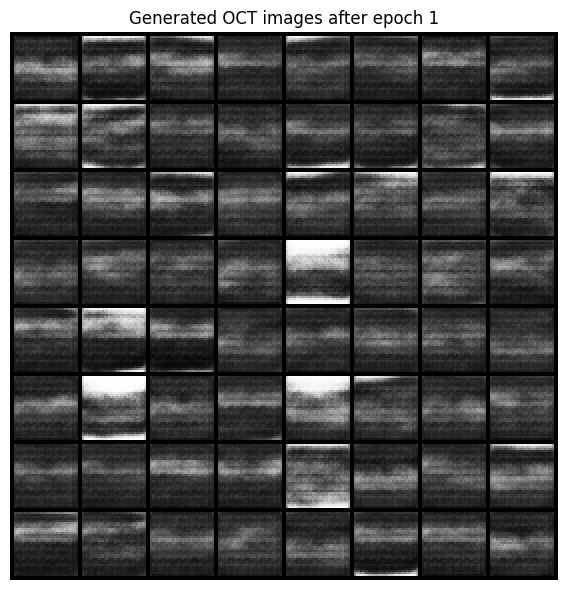

Epoch 2/20:   0%|          | 0/380 [00:00<?, ?it/s]

Epoch 3/20:   0%|          | 0/380 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f97040dc720>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f97040dc720>    
self._shutdown_workers()Traceback (most recent call last):

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    self._shutdown_workers()    if w.is_alive():
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers

      if w.is_alive():
          ^^ ^ ^^^^^^^^^^^^^^^
^^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^    ^assert self._parent_pid == os.getpid(), 'can only test a child process'^
^ 
   File "/usr/lib/pyth

Epoch 4/20:   0%|          | 0/380 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f97040dc720>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():Exception ignored in: 
<function _MultiProcessingDataLoaderIter.__del__ at 0x7f97040dc720> 
 Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
       self._shutdown_workers() 
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
^    ^if w.is_alive():^
 ^ ^ ^ ^ ^  ^^^^^
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^    assert self._parent_pid == os.getpid(), 'can only test a child process'^^
^    ^   ^^  ^  ^^^^^^
^^  File

Epoch 5/20:   0%|          | 0/380 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f97040dc720>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^Exception ignored in: ^<function _MultiProcessingDataLoaderIter.__del__ at 0x7f97040dc720>^^
Traceback (most recent call last):
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
^    ^self._shutdown_workers()^

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
        if w.is_alive():assert self._parent_pid == os.getpid(), 'can only test a child process'
 
  Exception ignored in:     <function _Mul

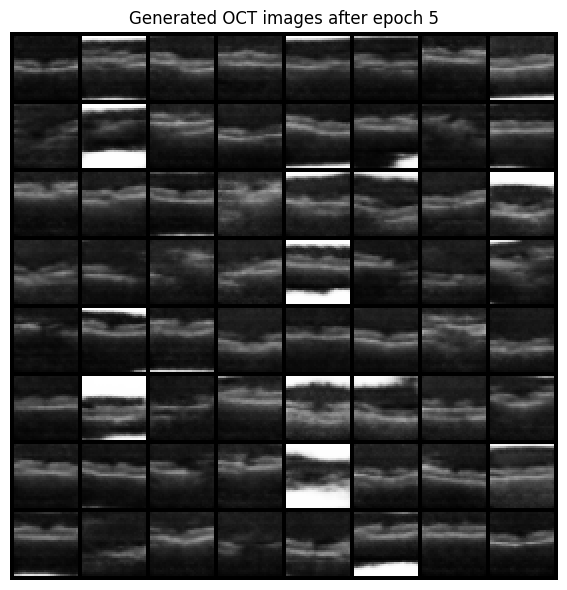

Epoch 6/20:   0%|          | 0/380 [00:00<?, ?it/s]

Epoch 7/20:   0%|          | 0/380 [00:00<?, ?it/s]

Epoch 8/20:   0%|          | 0/380 [00:00<?, ?it/s]

Epoch 9/20:   0%|          | 0/380 [00:00<?, ?it/s]

Epoch 10/20:   0%|          | 0/380 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f97040dc720>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f97040dc720>^
Traceback (most recent call last):
^^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
^    ^self._shutdown_workers()
^^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
^    ^^if w.is_alive():



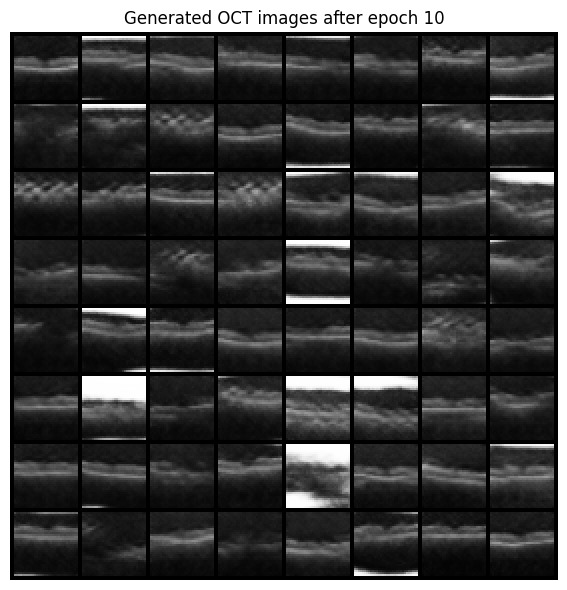

Epoch 11/20:   0%|          | 0/380 [00:00<?, ?it/s]

Epoch 12/20:   0%|          | 0/380 [00:00<?, ?it/s]

Epoch 13/20:   0%|          | 0/380 [00:00<?, ?it/s]

Epoch 14/20:   0%|          | 0/380 [00:00<?, ?it/s]

Epoch 15/20:   0%|          | 0/380 [00:00<?, ?it/s]

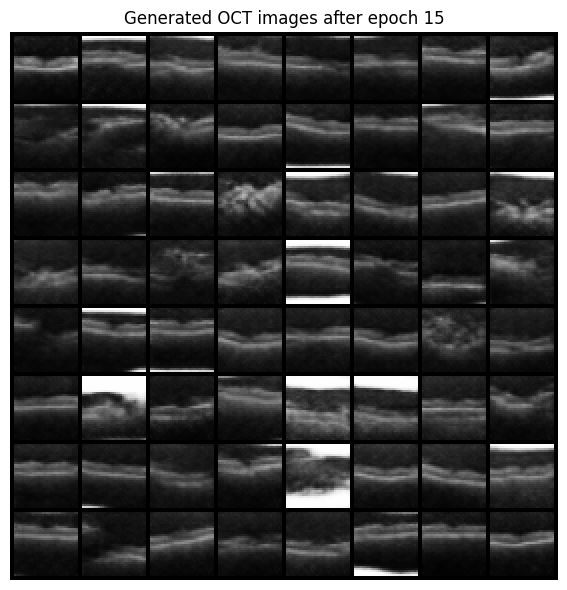

Epoch 16/20:   0%|          | 0/380 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f97040dc720>
Exception ignored in: Traceback (most recent call last):
<function _MultiProcessingDataLoaderIter.__del__ at 0x7f97040dc720>  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__

    Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
self._shutdown_workers()
      File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
self._shutdown_workers()    
if w.is_alive():  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers

    if w.is_alive(): 
             ^^^^^^^^^^^^^^^^^^^^^^^^

  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
        assert self.

Epoch 17/20:   0%|          | 0/380 [00:00<?, ?it/s]

Exception ignored in: Exception ignored in:   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
<function _MultiProcessingDataLoaderIter.__del__ at 0x7f97040dc720><function _MultiProcessingDataLoaderIter.__del__ at 0x7f97040dc720>

Traceback (most recent call last):
Traceback (most recent call last):
      File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
self._shutdown_workers()
      File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
self._shutdown_workers()    
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
if w.is_alive():
       if w.is_alive(): 
      ^ ^ ^^ ^^ ^^^^^^^^^^Exception ignored in: ^^^<function _MultiProcessingDataLoaderIter.__del__ at 0x7f97040dc720>^
^
^Traceback (most recent call last):
^  File "/usr/lib/python3.12/multiprocessing/process.py"

Epoch 18/20:   0%|          | 0/380 [00:00<?, ?it/s]

Epoch 19/20:   0%|          | 0/380 [00:00<?, ?it/s]

Epoch 20/20:   0%|          | 0/380 [00:00<?, ?it/s]

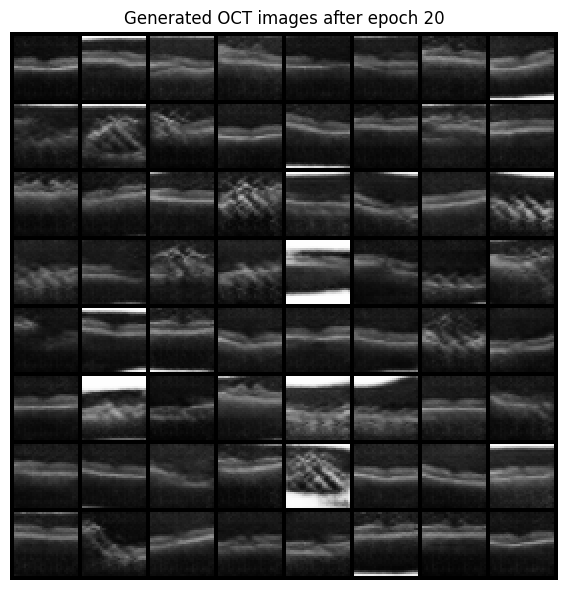

In [7]:
criterion = nn.BCEWithLogitsLoss()
optimiser_g = torch.optim.Adam(generator.parameters(), lr=LEARNING_RATE, betas=(0.5, 0.999))
optimiser_d = torch.optim.Adam(discriminator.parameters(), lr=LEARNING_RATE, betas=(0.5, 0.999))
fixed_noise = torch.randn(64, LATENT_DIM, 1, 1, device=DEVICE)
generator_losses: list[float] = []
discriminator_losses: list[float] = []

for epoch in range(1, EPOCHS + 1):
    generator.train()
    discriminator.train()
    epoch_g: list[float] = []
    epoch_d: list[float] = []
    progress = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}")

    for real_images, _ in progress:
        real_images = real_images.to(DEVICE, non_blocking=True)
        current_batch = real_images.size(0)

        # Train discriminator on real and detached fake images.
        optimiser_d.zero_grad(set_to_none=True)
        real_logits = discriminator(real_images)
        d_real = criterion(real_logits, torch.ones_like(real_logits))
        noise = torch.randn(current_batch, LATENT_DIM, 1, 1, device=DEVICE)
        fake_images = generator(noise)
        fake_logits = discriminator(fake_images.detach())
        d_fake = criterion(fake_logits, torch.zeros_like(fake_logits))
        d_loss = 0.5 * (d_real + d_fake)
        d_loss.backward()
        optimiser_d.step()

        # Train generator to make the discriminator label fakes as real.
        optimiser_g.zero_grad(set_to_none=True)
        generated_logits = discriminator(fake_images)
        g_loss = criterion(generated_logits, torch.ones_like(generated_logits))
        g_loss.backward()
        optimiser_g.step()

        epoch_g.append(float(g_loss.item()))
        epoch_d.append(float(d_loss.item()))
        progress.set_postfix(g=f"{g_loss.item():.3f}", d=f"{d_loss.item():.3f}")

    generator_losses.append(float(np.mean(epoch_g)))
    discriminator_losses.append(float(np.mean(epoch_d)))

    if epoch == 1 or epoch % 5 == 0 or epoch == EPOCHS:
        generator.eval()
        with torch.no_grad():
            checkpoint_samples = generator(fixed_noise)
        show_grid(
            checkpoint_samples,
            f"Generated OCT images after epoch {epoch}",
            OUTPUT_DIR / f"generated_epoch_{epoch:03d}.png",
        )



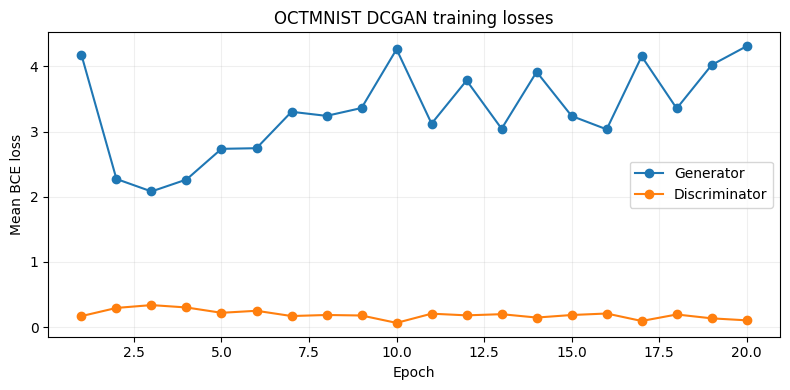

In [8]:
loss_table = pd.DataFrame(
    {
        "epoch": np.arange(1, EPOCHS + 1),
        "generator_loss": generator_losses,
        "discriminator_loss": discriminator_losses,
    }
)
loss_table.to_csv(OUTPUT_DIR / "training_losses.csv", index=False)

plt.figure(figsize=(8, 4))
plt.plot(loss_table["epoch"], loss_table["generator_loss"], marker="o", label="Generator")
plt.plot(loss_table["epoch"], loss_table["discriminator_loss"], marker="o", label="Discriminator")
plt.xlabel("Epoch")
plt.ylabel("Mean BCE loss")
plt.title("OCTMNIST DCGAN training losses")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "loss_curves.png", dpi=220, bbox_inches="tight")
plt.show()



## 4. Real-versus-generated comparison



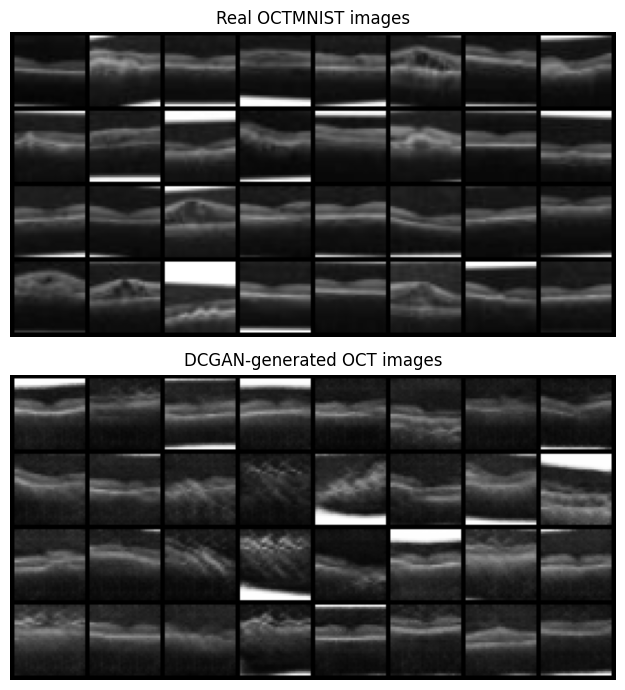

In [9]:
generator.eval()
real_comparison = next(iter(DataLoader(test_dataset, batch_size=32, shuffle=True)))[0]
with torch.no_grad():
    fake_comparison = generator(torch.randn(32, LATENT_DIM, 1, 1, device=DEVICE)).cpu()

fig, axes = plt.subplots(2, 1, figsize=(12, 7))
for axis, images, title in zip(
    axes,
    (real_comparison, fake_comparison),
    ("Real OCTMNIST images", "DCGAN-generated OCT images"),
):
    grid = make_grid(denormalise(images), nrow=8, padding=2)
    axis.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray", vmin=0, vmax=1)
    axis.set_title(title)
    axis.axis("off")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "real_vs_generated.png", dpi=220, bbox_inches="tight")
plt.show()



## 5. Fréchet Inception Distance (FID)

Inception expects three-channel images, so each grayscale image is repeated
across RGB channels. Both real and fake images receive identical processing.
FID is useful for comparison, but its ImageNet features are not specialised
for tiny medical images; this limitation must be stated in the report.



In [ ]:
@torch.no_grad()
def calculate_fid(
    trained_generator: nn.Module,
    real_dataset,
    number_of_samples: int = FID_SAMPLES,
) -> float:
    metric = FrechetInceptionDistance(feature=2048, normalize=True).to(DEVICE)
    loader = DataLoader(real_dataset, batch_size=128, shuffle=True, num_workers=NUM_WORKERS)
    seen = 0
    trained_generator.eval()

    for real_images, _ in tqdm(loader, desc="Calculating FID"):
        remaining = number_of_samples - seen
        if remaining <= 0:
            break
        real_images = real_images[:remaining].to(DEVICE)
        count = real_images.size(0)
        fake_images = trained_generator(torch.randn(count, LATENT_DIM, 1, 1, device=DEVICE))

        real_rgb = denormalise(real_images).to(DEVICE).repeat(1, 3, 1, 1)
        fake_rgb = denormalise(fake_images).to(DEVICE).repeat(1, 3, 1, 1)
        metric.update(real_rgb, real=True)
        metric.update(fake_rgb, real=False)
        seen += count

    if seen < number_of_samples:
        print(f"Warning: only {seen} real images were available for FID.")
    return float(metric.compute().cpu().item())


fid_score = calculate_fid(generator, val_dataset, min(FID_SAMPLES, len(val_dataset)))
print(f"OCTMNIST FID ({min(FID_SAMPLES, len(val_dataset))} real/fake images): {fid_score:.3f}")

metrics = {
    "fid": fid_score,
    "fid_samples": min(FID_SAMPLES, len(val_dataset)),
    "epochs": EPOCHS,
    "training_samples": len(train_dataset),
    "final_generator_loss": generator_losses[-1],
    "final_discriminator_loss": discriminator_losses[-1],
    "quick_run": QUICK_RUN,
    "seed": SEED,
}
(OUTPUT_DIR / "metrics.json").write_text(json.dumps(metrics, indent=2))
torch.save(generator.state_dict(), OUTPUT_DIR / "octmnist_generator.pt")
torch.save(discriminator.state_dict(), OUTPUT_DIR / "octmnist_discriminator.pt")



Calculating FID:   0%|          | 0/85 [00:00<?, ?it/s]

OCTMNIST FID (5000 real/fake images): 99.761


## 6. Optional extension — class-conditional GAN

Set `RUN_CGAN_EXTENSION=True` at the top and rerun the notebook. Labels are
embedded and supplied to both networks, allowing a requested OCT class to be
generated on demand.



In [10]:
class ConditionalOCTGenerator(nn.Module):
    def __init__(self, number_of_classes: int = NUM_CLASSES, embedding_dim: int = 16):
        super().__init__()
        self.label_embedding = nn.Embedding(number_of_classes, embedding_dim)
        self.project = nn.Sequential(
            nn.Linear(LATENT_DIM + embedding_dim, 256 * 4 * 4),
            nn.BatchNorm1d(256 * 4 * 4),
            nn.ReLU(True),
        )
        self.convolutions = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 1, 4, 2, 1, bias=False),
            nn.Tanh(),
        )

    def forward(self, noise: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
        noise = noise.view(noise.size(0), -1)
        combined = torch.cat((noise, self.label_embedding(labels)), dim=1)
        features = self.project(combined).view(-1, 256, 4, 4)
        return self.convolutions(features)


class ConditionalOCTDiscriminator(nn.Module):
    def __init__(self, number_of_classes: int = NUM_CLASSES):
        super().__init__()
        self.label_embedding = nn.Embedding(number_of_classes, IMAGE_SIZE * IMAGE_SIZE)
        self.discriminator = OCTDiscriminator(input_channels=2)

    def forward(self, images: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
        label_map = self.label_embedding(labels).view(-1, 1, IMAGE_SIZE, IMAGE_SIZE)
        return self.discriminator(torch.cat((images, label_map), dim=1))


if RUN_CGAN_EXTENSION:
    set_seed(SEED)
    c_generator = ConditionalOCTGenerator().to(DEVICE)
    c_discriminator = ConditionalOCTDiscriminator().to(DEVICE)
    c_generator.apply(initialise_weights)
    c_discriminator.apply(initialise_weights)
    c_opt_g = torch.optim.Adam(c_generator.parameters(), lr=LEARNING_RATE, betas=(0.5, 0.999))
    c_opt_d = torch.optim.Adam(c_discriminator.parameters(), lr=LEARNING_RATE, betas=(0.5, 0.999))
    c_g_losses: list[float] = []
    c_d_losses: list[float] = []

    for epoch in range(1, EPOCHS + 1):
        epoch_g, epoch_d = [], []
        for real_images, real_labels in tqdm(train_loader, desc=f"cGAN epoch {epoch}/{EPOCHS}"):
            real_images = real_images.to(DEVICE)
            real_labels = real_labels.view(-1).long().to(DEVICE)
            count = real_images.size(0)

            c_opt_d.zero_grad(set_to_none=True)
            real_logits = c_discriminator(real_images, real_labels)
            d_real = criterion(real_logits, torch.ones_like(real_logits))
            requested_labels = torch.randint(0, NUM_CLASSES, (count,), device=DEVICE)
            fake_images = c_generator(torch.randn(count, LATENT_DIM, device=DEVICE), requested_labels)
            fake_logits = c_discriminator(fake_images.detach(), requested_labels)
            d_fake = criterion(fake_logits, torch.zeros_like(fake_logits))
            d_loss = 0.5 * (d_real + d_fake)
            d_loss.backward()
            c_opt_d.step()

            c_opt_g.zero_grad(set_to_none=True)
            fake_logits = c_discriminator(fake_images, requested_labels)
            g_loss = criterion(fake_logits, torch.ones_like(fake_logits))
            g_loss.backward()
            c_opt_g.step()
            epoch_g.append(float(g_loss.item()))
            epoch_d.append(float(d_loss.item()))

        c_g_losses.append(float(np.mean(epoch_g)))
        c_d_losses.append(float(np.mean(epoch_d)))

    c_generator.eval()
    requested = torch.arange(NUM_CLASSES, device=DEVICE).repeat_interleave(8)
    with torch.no_grad():
        conditioned_samples = c_generator(
            torch.randn(len(requested), LATENT_DIM, device=DEVICE), requested
        )
    show_grid(
        conditioned_samples,
        "Conditional OCT images: eight requested examples per class",
        OUTPUT_DIR / "conditional_samples.png",
        nrow=8,
    )
    torch.save(c_generator.state_dict(), OUTPUT_DIR / "conditional_generator.pt")
    pd.DataFrame(
        {"epoch": range(1, EPOCHS + 1), "generator_loss": c_g_losses, "discriminator_loss": c_d_losses}
    ).to_csv(OUTPUT_DIR / "conditional_losses.csv", index=False)

print(f"Part 2.1 complete. Outputs saved to {OUTPUT_DIR.resolve()}")


Part 2.1 complete. Outputs saved to /content/outputs/octmnist
